# Check Data Augmentation tecnics for NeuroFlux Dataset

In [ ]:

import matplotlib.pyplot as plt
import torchvision.transforms as T
from PIL import Image
from glob import glob
import sys,os 
sys.path.append(os.path.abspath("../data"))

In [28]:
def show_image(tensor_img, title=None):
    img = tensor_img.squeeze().numpy()
    plt.imshow(img, cmap='gray')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


In [29]:
img_dir = '../data/IO'
img_paths = glob(os.path.join(img_dir, '*.jpg')) + glob(os.path.join(img_dir, '*.png'))
img_paths = sorted(img_paths)[:5]

images = [Image.open(p).convert('L') for p in img_paths]

In [ ]:
base_transforms = [
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.5], std=[0.5])
    ]

augmentations = {
    'Horizontal Flip': T.RandomHorizontalFlip(),
    'Vertical Flip': T.RandomVerticalFlip(p=0.5),
    'Rotation': T.RandomRotation(15),
    'Rotation Degree' : T.RandomRotation(degrees=10),
    'Gaussian Blur': T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
}

def apply_transform(image, transform):
    composed = T.Compose([transform] + base_transforms)
    return composed(image).squeeze().numpy()

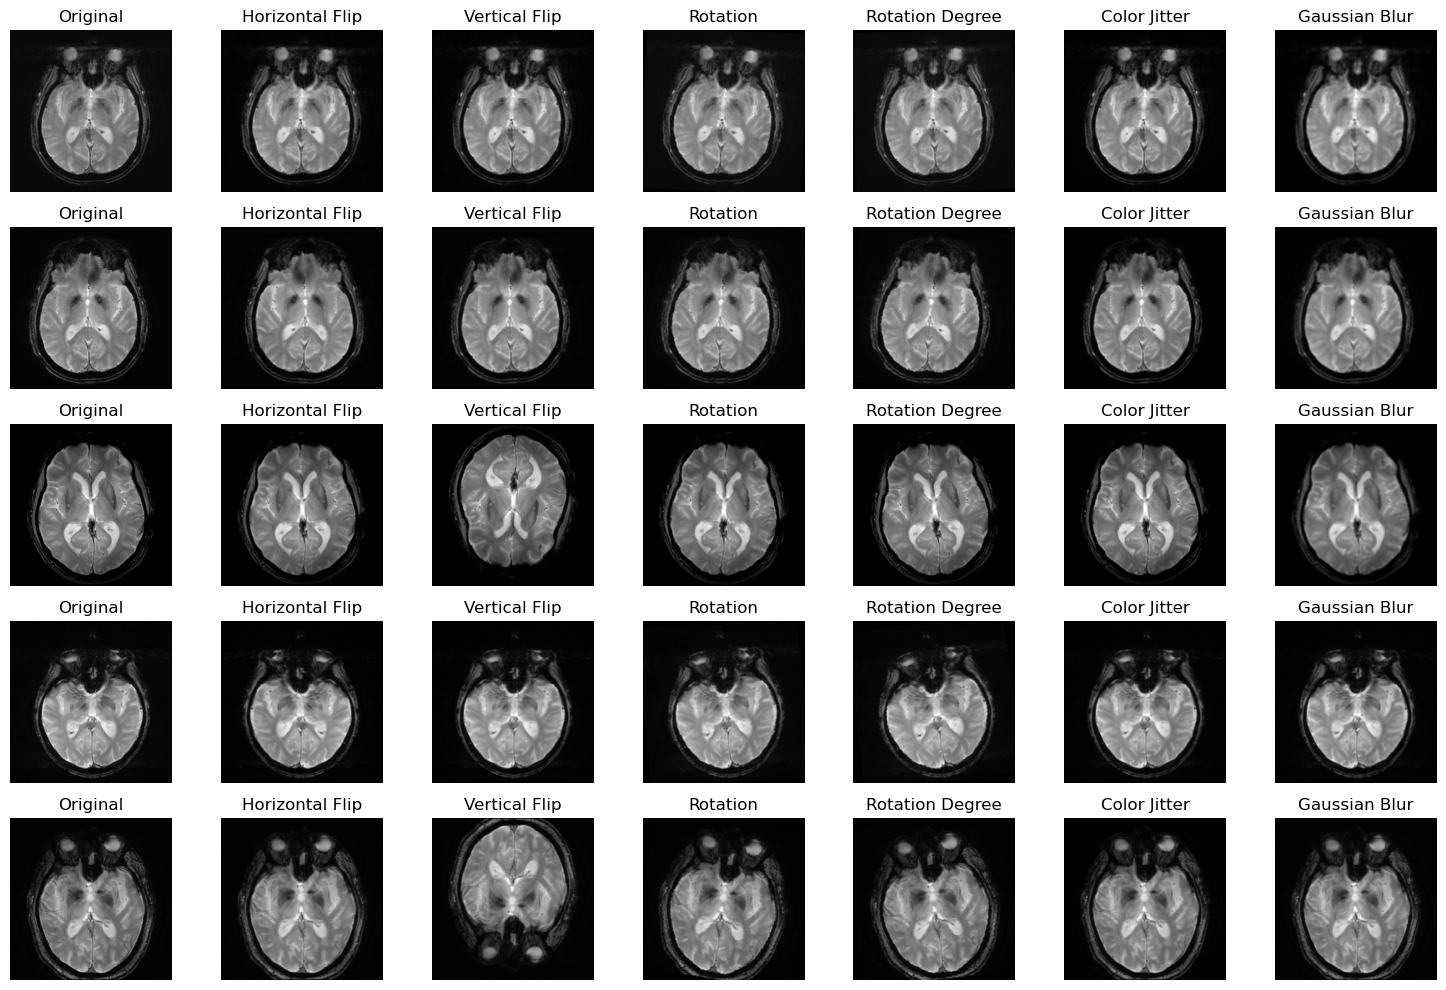

In [31]:
fig, axs = plt.subplots(len(images), len(augmentations)+1, figsize=(15, 10))

for row, img in enumerate(images):
    axs[row][0].imshow(img, cmap='gray')
    axs[row][0].set_title("Original")
    axs[row][0].axis('off')

    for col, (name, aug) in enumerate(augmentations.items()):
        aug_img = apply_transform(img, aug)
        axs[row][col+1].imshow(aug_img, cmap='gray')
        axs[row][col+1].set_title(name)
        axs[row][col+1].axis('off')

plt.tight_layout()
plt.show()
